In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
from sklearn import preprocessing
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform
from sklearn.metrics.pairwise import haversine_distances
import glob
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import cmcrameri.cm as cm
import colorcet as cc


# default colormap to batlow
plt.rcParams['image.cmap'] = 'cmc.batlow'

In [16]:
def half_ellipse(X, Y, x0=0, y0=0, a=2, b=1, rotation=0, rotation_unit="radians", include_sign=False):
    """
    Returns the value of the half-ellipse function at points (X, Y).
    Inside half-ellipse if value <= 1.
    Parameters:
    X : np.ndarray
        X-coordinates of the points.
    Y : np.ndarray
        Y-coordinates of the points.
    a : float
        Axis length towards the rotation direction.
    b : float
        Axis length perpendicular to the rotation direction.
    rotation : float
        Rotation angle in unit determined by "rotation_unit".
    rotation_unit : str
        'radians' or 'degrees' for the rotation angle.
    Returns:
    np.ndarray
        Values of the half-ellipse function at (X, Y).
    """
    if rotation_unit == "degrees":
        rotation = np.deg2rad(rotation)
    sin = np.sin(rotation)
    cos = np.cos(rotation)
    X_rot = cos * (X - x0) + sin * (Y - y0)
    Y_rot = -sin * (X - x0) + cos * (Y - y0)
    if include_sign:
        sign = np.sign(X_rot)
    else:
        sign = 1
    return sign * np.sqrt((X_rot / np.where(X_rot >= 0, a, b)) ** 2 + (Y_rot / b) ** 2)




def wind_to_angle_and_magnitude(wind_vector):
    """
    Converts a wind vector or array of wind vectors to angle(s) and magnitude(ies).
    
    Parameters:
    wind_vector : np.ndarray
        Wind vector(s) with the last dimension being 2 (for [wx, wy]).
        Can be 1D [wx, wy], 2D (n, 2), 3D (n, m, 2), or higher dimensions.
    
    Returns:
    tuple
        (wind_angles, wind_magnitudes) with the same shape as the input,
        except the last dimension is removed (since it contained [wx, wy]).
        wind_angle(s) are in radians.
    
    Example:
        Single vector [1, 1] -> scalar, scalar
        Multiple vectors (3, 2) -> (3,), (3,)
        Grid of vectors (n, m, 2) -> (n, m), (n, m)
    """
    wind_vector = np.asarray(wind_vector)
    
    if wind_vector.shape[-1] != 2:
        raise ValueError(f"Last dimension must be 2 (for [wx, wy]), got shape {wind_vector.shape}")
    
    # Avoid -0.0 issues
    wind_vector = wind_vector.copy()
    wind_vector[wind_vector == 0] = 0
    
    # Extract wx and wy using the last dimension
    wx = wind_vector[..., 0]
    wy = wind_vector[..., 1]
    
    wind_magnitude = np.sqrt(wx ** 2 + wy ** 2)
    wind_angle = np.arctan2(wy, wx)
    
    return wind_angle, wind_magnitude



def calc_half_ellipse_distance_matrix(X, Y, magnitude, rotation, rotation_unit="radians", include_sign=False):
    """
    Computes the pairwise half-ellipse distance matrix for the given points,
    considering wind direction and magnitude.
    Returns:
    np.ndarray
        Pairwise half-ellipse distance matrix.
    """
    X = X.flatten()
    Y = Y.flatten()

    if np.isscalar(magnitude):
        magnitude = np.full(X.shape, magnitude)
    else:
        magnitude = magnitude.flatten()
    if len(magnitude) != len(X):
        raise ValueError("Magnitude array length must match number of points.")
    
    if np.isscalar(rotation):
        rotation = np.full(X.shape, rotation)
    else:
        rotation = rotation.flatten()
    if len(rotation) != len(X):
        raise ValueError("Rotation array length must match number of points.")
    
    half_ellipse_distance_matrix = np.zeros((X.shape[0], X.shape[0]))

    for i in range(X.shape[0]):
        half_ellipse_distance_matrix[i] = half_ellipse(
            X,
            Y,
            x0=X[i],
            y0=Y[i],
            a=1+magnitude[i],
            b=1,
            rotation=rotation[i],
            rotation_unit=rotation_unit,
            include_sign=include_sign,
        )

    return half_ellipse_distance_matrix


# ============================================================================================


def find_one_cluster_with_wind_only_distance_matrix(
    points,
    point_value,
    radius_func="default",
    growth_limit=2,
    distance_matrix="euclidean",
    max_points_in_start_radius=7,
    preprocessor="Standard",
    wind=None,
    wind_angle=None,
    wind_magnitude=None,
):
    """
    Stars with radius thats equal to distance to closest point, and then applies the radius function.

    """

    if radius_func == "default":
        radius_func = lambda x: np.min([1 + x - growth_limit, 2])

    # Preprocessing
    if preprocessor == "Standard":
        point_value = (
            preprocessing.StandardScaler()
            .fit_transform(point_value.reshape(-1, 1))
            .flatten()
        )
    elif preprocessor == "Quantile":
        point_value = (
            preprocessing.QuantileTransformer(
                output_distribution="uniform", n_quantiles=3
            )
            .fit_transform(point_value.reshape(-1, 1))
            .flatten()
        )
    elif preprocessor == "None":
        pass
    else:
        point_value = preprocessor.fit_transform(point_value.reshape(-1, 1)).flatten()

    # Distance matrix for points
    if isinstance(distance_matrix, str):
        if distance_matrix == "euclidean":
            distance_matrix = squareform(pdist(points))
        elif distance_matrix == "haversine":
            distance_matrix = (
                haversine_distances(np.radians(points)) * 6371000 / 1000
            )  # multiply by Earth radius to get kilometers
        elif distance_matrix == "half_ellipse":
            if wind is None and (wind_angle is None or wind_magnitude is None):
                raise Exception(
                    "Wind vector or wind parameters must be provided for half_ellipse distance matrix"
                )
            if wind is not None:
                if wind_angle is not None or wind_magnitude is not None:
                    print(
                        "Warning: Both wind vector and wind parameters provided. Using wind vector."
                    )
                wind_angle, wind_magnitude = wind_to_angle_and_magnitude(wind)
            distance_matrix = calc_half_ellipse_distance_matrix(
                points[:, 0],
                points[:, 1],
                magnitude=1 + wind_magnitude,
                rotation=wind_angle,
                rotation_unit="radians",
            )
        else:
            raise Exception("Unknown distance_matrix option")

    # Initialize cluster
    cluster = np.zeros(len(points), dtype=bool)
    radiating_points = np.zeros(len(points), dtype=bool)

    # Find the index with max point_value value. Add it to the cluster
    argmax = np.argmax(point_value)
    cluster[argmax] = True
    radiating_points[argmax] = True

    # Find points around of added_points that are not already in the cluster. These are the new points.
    while True:
        not_old_points = np.logical_not(cluster)
        new_points = np.zeros(len(points), dtype=bool)  # initialize array with Falses

        # If there are no points left to add, break
        if not_old_points.sum() == 0:
            break

        # Find points added in this iteration
        for i in np.nonzero(radiating_points)[0]:
            # try:
            #    radius_of_closest_point_not_in_cluster = np.min(
            #        distance_matrix[i][not_old_points]
            #    )
            # except:
            #    pass
            radius_of_closest_point_not_in_cluster = np.min(
                distance_matrix[i][not_old_points]
            )
            min_index = np.min(
                [len(distance_matrix[i]) - 1, max_points_in_start_radius]
            )
            radius_of_nth_closest_point = np.partition(distance_matrix[i], min_index)[
                min_index
            ]

            points_in_radius = distance_matrix[
                i
            ] < radius_of_closest_point_not_in_cluster * radius_func(point_value[i])
            if (
                radius_of_closest_point_not_in_cluster < radius_of_nth_closest_point
            ) and (points_in_radius.sum() != 0):
                new_points = np.logical_or(
                    new_points, np.logical_and(points_in_radius, not_old_points)
                )
            else:
                # Stop radiating
                radiating_points[i] = False

        cluster = np.logical_or(new_points, cluster)  # Add new point to cluster
        radiating_points = np.logical_or(
            radiating_points, new_points
        )  # get index of added points

        # Stop when no new points are added
        if new_points.sum() == 0:
            break

    return cluster



def crop_to_bbox(
    ds, 
    bbox: list[float] = [-10.0, 35.0, 30.0, 70.0],  # [min_lon, min_lat, max_lon, max_lat]
    save_path: str = None
) -> xr.Dataset:
    """
    Crop xarray Dataset to given bbox.
    """

    if type(ds) is not xr.Dataset:
        ds = xr.open_dataset(ds, group="PRODUCT", mask_and_scale=True)

    print("[+] Pre-processing data files ...")

    # Open dataset
    lon = ds['longitude'][0].data
    lat = ds['latitude'][0].data

    # Mask for points inside bbox
    in_bbox = (lon >= bbox[0]) & (lon <= bbox[2]) & \
                (lat >= bbox[1]) & (lat <= bbox[3])

    if np.any(in_bbox):

        # Find valid rows/cols (at least one point in bbox)
        valid_rows = np.any(in_bbox, axis=1)
        valid_cols = np.any(in_bbox, axis=0)

        in_bbox = in_bbox[valid_rows, :][:, valid_cols]

        ds_crop = ds.isel(scanline=valid_rows, ground_pixel=valid_cols)

        for vars in ds_crop.variables:
            if (("scanline" in ds_crop[vars].coords) 
                and ("ground_pixel" in ds_crop[vars].coords) 
                and (ds_crop[vars].shape == in_bbox.shape) 
                and (vars not in ["time", "latitude", "longitude", "time_utc"])
                ):
                print("[+] Found 'scanline' and 'ground_pixel' coordinates in", vars)
                # Turn values outside bbox to NaN
                ds_crop[vars] = ds_crop[vars].where(in_bbox)

    else:
        print(f"[-] No data in bbox for file")


    if save_path:
        ds_crop.to_netcdf(save_path)
        print(f"[+] Saved cropped dataset to {save_path}")

    return ds_crop



# ============================================================================================


def find_one_cluster_v31(
    points,
    point_value,
    radius_func="default",
    growth_limit=2,
    distance_matrix="euclidean",
    max_points_in_start_radius=7,
    preprocessor="Standard",
):
    """
    Stars with radius thats equal to distance to closest point, and then applies the radius function.

    """

    if radius_func == "default":
        radius_func = lambda x: np.min([1 + x - growth_limit, 2])

    # Preprocessing
    if preprocessor == "Standard":
        point_value = (
            preprocessing.StandardScaler()
            .fit_transform(point_value.reshape(-1, 1))
            .flatten()
        )
    elif preprocessor == "Quantile":
        point_value = (
            preprocessing.QuantileTransformer(
                output_distribution="uniform", n_quantiles=3
            )
            .fit_transform(point_value.reshape(-1, 1))
            .flatten()
        )
    elif preprocessor == "None":
        pass
    else:
        point_value = preprocessor.fit_transform(point_value.reshape(-1, 1)).flatten()

    # Distance matrix for points
    if isinstance(distance_matrix, str):
        if distance_matrix == "euclidean":
            distance_matrix = squareform(pdist(points))
        elif distance_matrix == "haversine":
            distance_matrix = (
                haversine_distances(np.radians(points)) * 6371000 / 1000
            )  # multiply by Earth radius to get kilometers
        else:
            raise Exception("Unknown distance_matrix option")

    # Initialize cluster
    cluster = np.zeros(len(points), dtype=bool)
    radiating_points = np.zeros(len(points), dtype=bool)

    # Find the index with max point_value value. Add it to the cluster
    argmax = np.argmax(point_value)
    cluster[argmax] = True
    radiating_points[argmax] = True

    # Find points around of added_points that are not already in the cluster. These are the new points.
    while True:
        not_old_points = np.logical_not(cluster)
        new_points = np.zeros(len(points), dtype=bool)  # initialize array with Falses

        # If there are no points left to add, break
        if not_old_points.sum() == 0:
            break

        # Find points added in this iteration
        for i in np.nonzero(radiating_points)[0]:
            # try:
            #    radius_of_closest_point_not_in_cluster = np.min(
            #        distance_matrix[i][not_old_points]
            #    )
            # except:
            #    pass
            radius_of_closest_point_not_in_cluster = np.min(
                distance_matrix[i][not_old_points]
            )
            min_index = np.min(
                [len(distance_matrix[i]) - 1, max_points_in_start_radius]
            )
            radius_of_nth_closest_point = np.partition(distance_matrix[i], min_index)[
                min_index
            ]

            points_in_radius = distance_matrix[
                i
            ] < radius_of_closest_point_not_in_cluster * radius_func(point_value[i])
            if (
                radius_of_closest_point_not_in_cluster < radius_of_nth_closest_point
            ) and (points_in_radius.sum() != 0):
                new_points = np.logical_or(
                    new_points, np.logical_and(points_in_radius, not_old_points)
                )
            else:
                # Stop radiating
                radiating_points[i] = False

        cluster = np.logical_or(new_points, cluster)  # Add new point to cluster
        radiating_points = np.logical_or(
            radiating_points, new_points
        )  # get index of added points

        # Stop when no new points are added
        if new_points.sum() == 0:
            break

    return cluster


# ============================================================================================


def find_one_cluster_with_wind_larger_radius(
    points,
    point_value,
    radius_func="default",
    growth_limit=2,
    distance_matrix="euclidean",
    max_points_in_start_radius=7,
    preprocessor="Standard",
    wind=None,
    wind_angle=None,
    wind_magnitude=None,
):
    """
    Starts with radius thats equal to distance to closest point, and then applies the radius function.

    """

    if radius_func == "default":
        radius_func = lambda x: np.min([1 + x - growth_limit, 2])

    # Preprocessing
    if preprocessor == "Standard":
        point_value = (
            preprocessing.StandardScaler()
            .fit_transform(point_value.reshape(-1, 1))
            .flatten()
        )
    elif preprocessor == "Quantile":
        point_value = (
            preprocessing.QuantileTransformer(
                output_distribution="uniform", n_quantiles=3
            )
            .fit_transform(point_value.reshape(-1, 1))
            .flatten()
        )
    elif preprocessor == "None":
        pass
    else:
        point_value = preprocessor.fit_transform(point_value.reshape(-1, 1)).flatten()

    # Distance matrix for points
    if isinstance(distance_matrix, str):
        if distance_matrix == "euclidean":
            distance_matrix = squareform(pdist(points))
        elif distance_matrix == "haversine":
            distance_matrix = (
                haversine_distances(np.radians(points)) * 6371000 / 1000
            )  # multiply by Earth radius to get kilometers
        elif distance_matrix == "half_ellipse":
            if wind is None and (wind_angle is None or wind_magnitude is None):
                raise Exception(
                    "Wind vector or wind parameters must be provided for half_ellipse distance matrix"
                )
            if wind is not None:
                if wind_angle is not None or wind_magnitude is not None:
                    print(
                        "Warning: Both wind vector and wind parameters provided. Using wind vector."
                    )
                wind_angle, wind_magnitude = wind_to_angle_and_magnitude(wind)

            distance_matrix_ellipse = calc_half_ellipse_distance_matrix(
                            points[:, 0],
                            points[:, 1],
                            magnitude=1 + wind_magnitude,
                            rotation=wind_angle,
                            rotation_unit="radians",
                            include_sign=True,
                        )
            distance_matrix_ellipse[distance_matrix_ellipse <= 0] = np.inf  # only consider half-ellipse in wind direction
            distance_matrix_circle = squareform(pdist(points))

        else:
            raise Exception("Unknown distance_matrix option")

    # Initialize cluster
    cluster = np.zeros(len(points), dtype=bool)
    radiating_points = np.zeros(len(points), dtype=bool)

    # Find the index with max point_value value. Add it to the cluster
    argmax = np.argmax(point_value)
    cluster[argmax] = True
    radiating_points[argmax] = True

    # Find points around of added_points that are not already in the cluster. These are the new points.
    while True:
        not_old_points = np.logical_not(cluster)
        new_points = np.zeros(len(points), dtype=bool)  # initialize array with Falses

        # If there are no points left to add, break
        if not_old_points.sum() == 0:
            break

        # Find points added in this iteration
        for i in np.nonzero(radiating_points)[0]:
            # try:
            #    radius_of_closest_point_not_in_cluster = np.min(
            #        distance_matrix[i][not_old_points]
            #    )
            # except:
            #    pass
            radius_of_closest_point_not_in_cluster = np.min(
                distance_matrix_circle[i][not_old_points]
            )
            min_index = np.min(
                [len(distance_matrix_circle[i]) - 1, max_points_in_start_radius]
            )  # if there are less points than max_points_in_start_radius
            radius_of_nth_closest_point = np.partition(distance_matrix_circle[i], min_index)[
                min_index
            ]
            
            threshold = radius_of_closest_point_not_in_cluster * radius_func(point_value[i])
            points_in_radius_circle = distance_matrix_circle[i] < threshold
            points_in_radius_ellipse = distance_matrix_ellipse[i] < threshold
            points_in_radius = np.logical_or(
                points_in_radius_circle, points_in_radius_ellipse
            )


            if (
                radius_of_closest_point_not_in_cluster < radius_of_nth_closest_point
            ) and (points_in_radius_circle.sum() != 0):
                new_points = np.logical_or(
                    new_points, np.logical_and(points_in_radius, not_old_points)
                )
            else:
                # Stop radiating
                radiating_points[i] = False

        cluster = np.logical_or(new_points, cluster)  # Add new point to cluster
        radiating_points = np.logical_or(
            radiating_points, new_points
        )  # get index of added points

        # Stop when no new points are added
        if new_points.sum() == 0:
            break

    return cluster

In [17]:
X = np.linspace(-5, 5, 101)
Y = np.linspace(-5, 5, 101)
X, Y = np.meshgrid(X, Y)


points = np.transpose([X.flatten(), Y.flatten()])

half_ellipse_distance_matrix = np.zeros((points.shape[0], points.shape[0]))

a0=2
b0=1
wind = [1,0]
wind_angle, wind_magnitude = wind_to_angle_and_magnitude(wind)
    
for i in range(points.shape[0]):
    half_ellipse_distance_matrix[i] = half_ellipse(points[:,0], points[:,1], x0=points[i,0], y0=points[i,1], a=a0*wind_magnitude, b=b0, rotation=wind_angle, rotation_unit='radians')

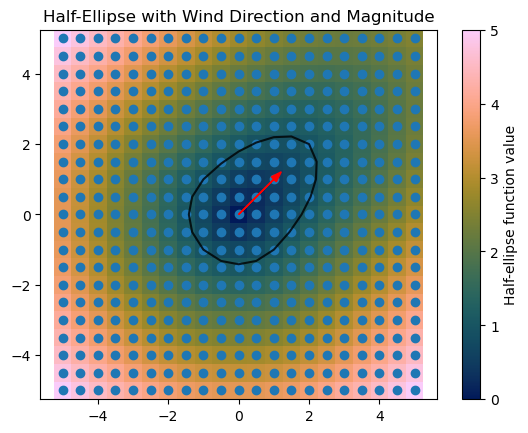

In [18]:
X = np.linspace(-5, 5, 21)
Y = np.linspace(-5, 5, 21)
X, Y = np.meshgrid(X, Y)

wind = (1,1)
wind_angle, wind_magnitude = wind_to_angle_and_magnitude(wind)

asdf = plt.pcolormesh(X, Y, half_ellipse(X, Y, a=2*wind_magnitude, b=1*wind_magnitude, rotation=wind_angle, rotation_unit='radians'), shading='auto')
plt.contour(X, Y, half_ellipse(X, Y, a=2*wind_magnitude, b=1*wind_magnitude, rotation=wind_angle, rotation_unit='radians'), levels=[1], colors='black', alpha=0.8)
plt.scatter(X,Y)
plt.arrow(0, 0, wind[0], wind[1], head_width=0.2, head_length=0.3, fc='red', ec='red')
plt.axis('equal')
plt.colorbar(asdf, label='Half-ellipse function value')
plt.title('Half-Ellipse with Wind Direction and Magnitude')
#plt.xlabel('X')
#plt.ylabel('Y')
plt.show()

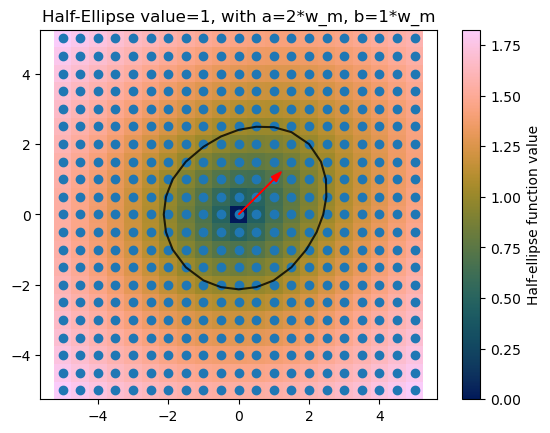

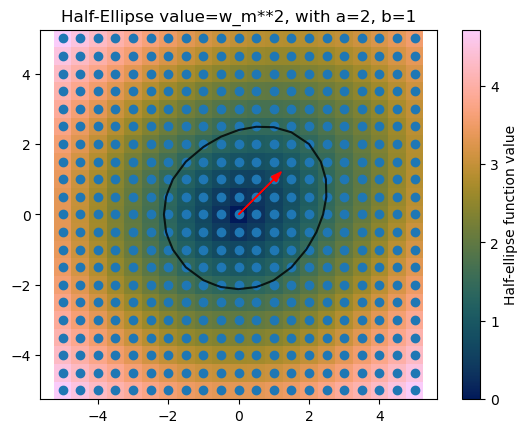

In [19]:
X = np.linspace(-5, 5, 21)
Y = np.linspace(-5, 5, 21)
X, Y = np.meshgrid(X, Y)

wind = (1,1)
wind_angle, wind_magnitude = wind_to_angle_and_magnitude(wind)
a0 = 2
b0 = 1.5

half_ellipse_values = np.sqrt(half_ellipse(X, Y, a=a0*wind_magnitude, b=b0*wind_magnitude, rotation=wind_angle, rotation_unit='radians'))

asdf = plt.pcolormesh(X, Y, half_ellipse_values, shading='auto')
plt.contour(X, Y, half_ellipse_values, levels=[1], colors='black', alpha=0.8)
plt.scatter(X,Y)
plt.arrow(0, 0, wind[0], wind[1], head_width=0.2, head_length=0.3, fc='red', ec='red')
plt.axis('equal')
plt.colorbar(asdf, label='Half-ellipse function value')
plt.title('Half-Ellipse value=1, with a=2*w_m, b=1*w_m')
#plt.xlabel('X')
#plt.ylabel('Y')
plt.show()







X = np.linspace(-5, 5, 21)
Y = np.linspace(-5, 5, 21)
X, Y = np.meshgrid(X, Y)

wind = (1,1)
wind_angle, wind_magnitude = wind_to_angle_and_magnitude(wind)
half_ellipse_values = half_ellipse(X, Y, a=a0, b=b0, rotation=wind_angle, rotation_unit='radians')

asdf = plt.pcolormesh(X, Y, half_ellipse_values, shading='auto')
plt.contour(X, Y, half_ellipse_values, levels=[wind_magnitude], colors='black', alpha=0.8)
plt.scatter(X,Y)
plt.arrow(0, 0, wind[0], wind[1], head_width=0.2, head_length=0.3, fc='red', ec='red')
plt.axis('equal')
plt.colorbar(asdf, label='Half-ellipse function value')
plt.title('Half-Ellipse value=w_m**2, with a=2, b=1')
#plt.xlabel('X')
#plt.ylabel('Y')
plt.show()

In [20]:
X = np.linspace(-5, 5, 101)
Y = np.linspace(-5, 5, 101)
X, Y = np.meshgrid(X, Y)


points = np.transpose([X.flatten(), Y.flatten()])

half_ellipse_distance_matrix = np.zeros((points.shape[0], points.shape[0]))

a0=2
b0=1
wind = [1,0]
wind_angle, wind_magnitude = wind_to_angle_and_magnitude(wind)
    
for i in range(points.shape[0]):
    half_ellipse_distance_matrix[i] = half_ellipse(points[:,0], points[:,1], x0=points[i,0], y0=points[i,1], a=a0*wind_magnitude, b=b0, rotation=wind_angle, rotation_unit='radians')

half_ellipse_distance_matrix

array([[ 0.        ,  0.05      ,  0.1       , ..., 11.13597773,
        11.15806883, 11.18033989],
       [ 0.1       ,  0.        ,  0.05      , ..., 11.11406766,
        11.13597773, 11.15806883],
       [ 0.2       ,  0.1       ,  0.        , ..., 11.0923397 ,
        11.11406766, 11.13597773],
       ...,
       [14.0014285 , 13.93161871, 13.86217876, ...,  0.        ,
         0.05      ,  0.1       ],
       [14.07160261, 14.0014285 , 13.93161871, ...,  0.1       ,
         0.        ,  0.05      ],
       [14.14213562, 14.07160261, 14.0014285 , ...,  0.2       ,
         0.1       ,  0.        ]], shape=(10201, 10201))

In [55]:
X = np.linspace(-5, 5, 101)
Y = np.linspace(-5, 5, 101)
X, Y = np.meshgrid(X, Y)

a0=2
b0=1
wind = (1,0.5)
wind_angle, wind_magnitude = wind_to_angle_and_magnitude(wind)

%timeit half_ellipse_distance_matrix = calc_half_ellipse_distance_matrix(X,Y, magnitude=a0*wind_magnitude, rotation=wind_angle, rotation_unit='radians')

half_ellipse_distance_matrix[:4, :4]

575 ms ± 36.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


array([[0.  , 0.05, 0.1 , 0.15],
       [0.1 , 0.  , 0.05, 0.1 ],
       [0.2 , 0.1 , 0.  , 0.05],
       [0.3 , 0.2 , 0.1 , 0.  ]])

In [56]:
circle_distance_matrix = np.zeros((points.shape[0], points.shape[0]))
for i in range(points.shape[0]):
    circle_distance_matrix[i] = np.sqrt((points[:,0]-points[i,0])**2 + (points[:,1]-points[i,1])**2)

circle_distance_matrix

array([[ 0.        ,  0.1       ,  0.2       , ..., 14.0014285 ,
        14.07160261, 14.14213562],
       [ 0.1       ,  0.        ,  0.1       , ..., 13.93161871,
        14.0014285 , 14.07160261],
       [ 0.2       ,  0.1       ,  0.        , ..., 13.86217876,
        13.93161871, 14.0014285 ],
       ...,
       [14.0014285 , 13.93161871, 13.86217876, ...,  0.        ,
         0.1       ,  0.2       ],
       [14.07160261, 14.0014285 , 13.93161871, ...,  0.1       ,
         0.        ,  0.1       ],
       [14.14213562, 14.07160261, 14.0014285 , ...,  0.2       ,
         0.1       ,  0.        ]])

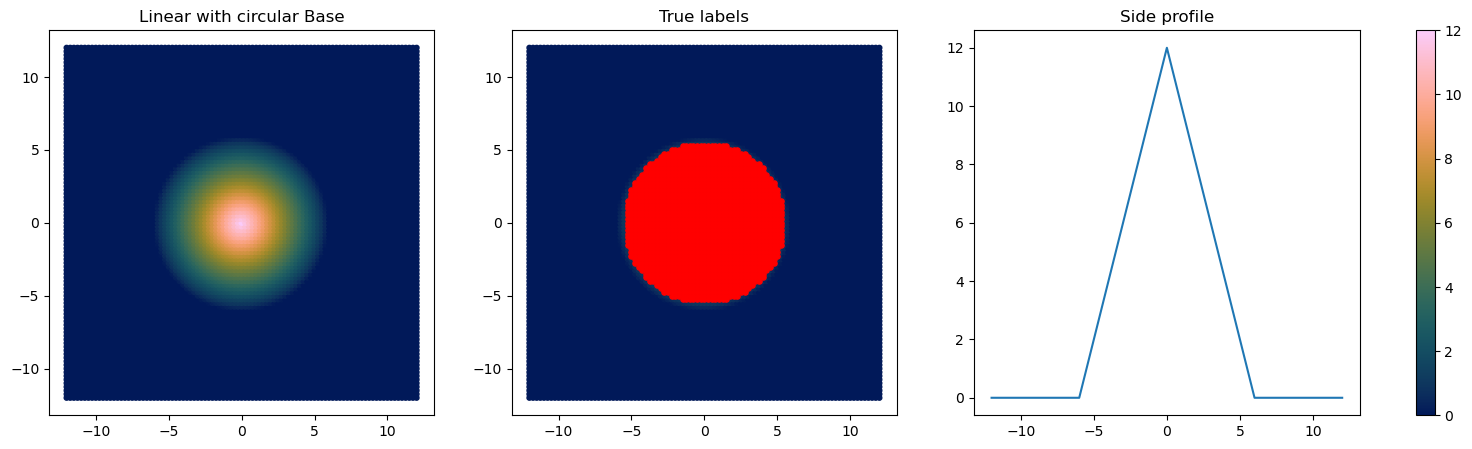

In [57]:
# Define the polar linear data
# Define the function in polar coordinates

linear_function_polar = lambda r: np.maximum(-r * 2 + 12, 0)

meshgrid = np.meshgrid(np.linspace(-12, 12, 97), np.linspace(-12, 12, 97))
x = meshgrid[0].flatten()
y = meshgrid[1].flatten()

# Convert Cartesian coordinates to polar coordinates
R = np.sqrt(x**2 + y**2)  # How far the grid point is from the origin

values = linear_function_polar(R)


points_linear_polar = np.array([x, y]).T
x_linear_polar = x
y_linear_polar = y
meshgrid_linear_polar = meshgrid
values_linear_polar = values
labels_linear_polar = values > 1



# With polar coordinates, so that the base is circular

x = x_linear_polar
y = y_linear_polar
values = values_linear_polar
labels = labels_linear_polar


# Plot the function
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs = axs.flatten()

# 1st plot
sc = axs[0].scatter(x.flatten(), y.flatten(), c=values.flatten(), s=12)
axs[0].set_title("Linear with circular Base")
axs[0].set_aspect("equal")

# 2nd plot
axs[1].scatter(x, y, c=values, s=12)
axs[1].scatter(x[labels], y[labels], s=14, c="r")
axs[1].set_title("True labels")
axs[1].set_aspect("equal")

# 3rd plot
axs[2].plot(x[np.where(y == 0)], linear_function_polar(R[np.where(y == 0)]))
axs[2].set_title("Side profile")

# Create a colorbar with its own axis
cbar = fig.colorbar(sc, ax=axs, orientation="vertical", fraction=0.02, pad=0.04)

plt.show()

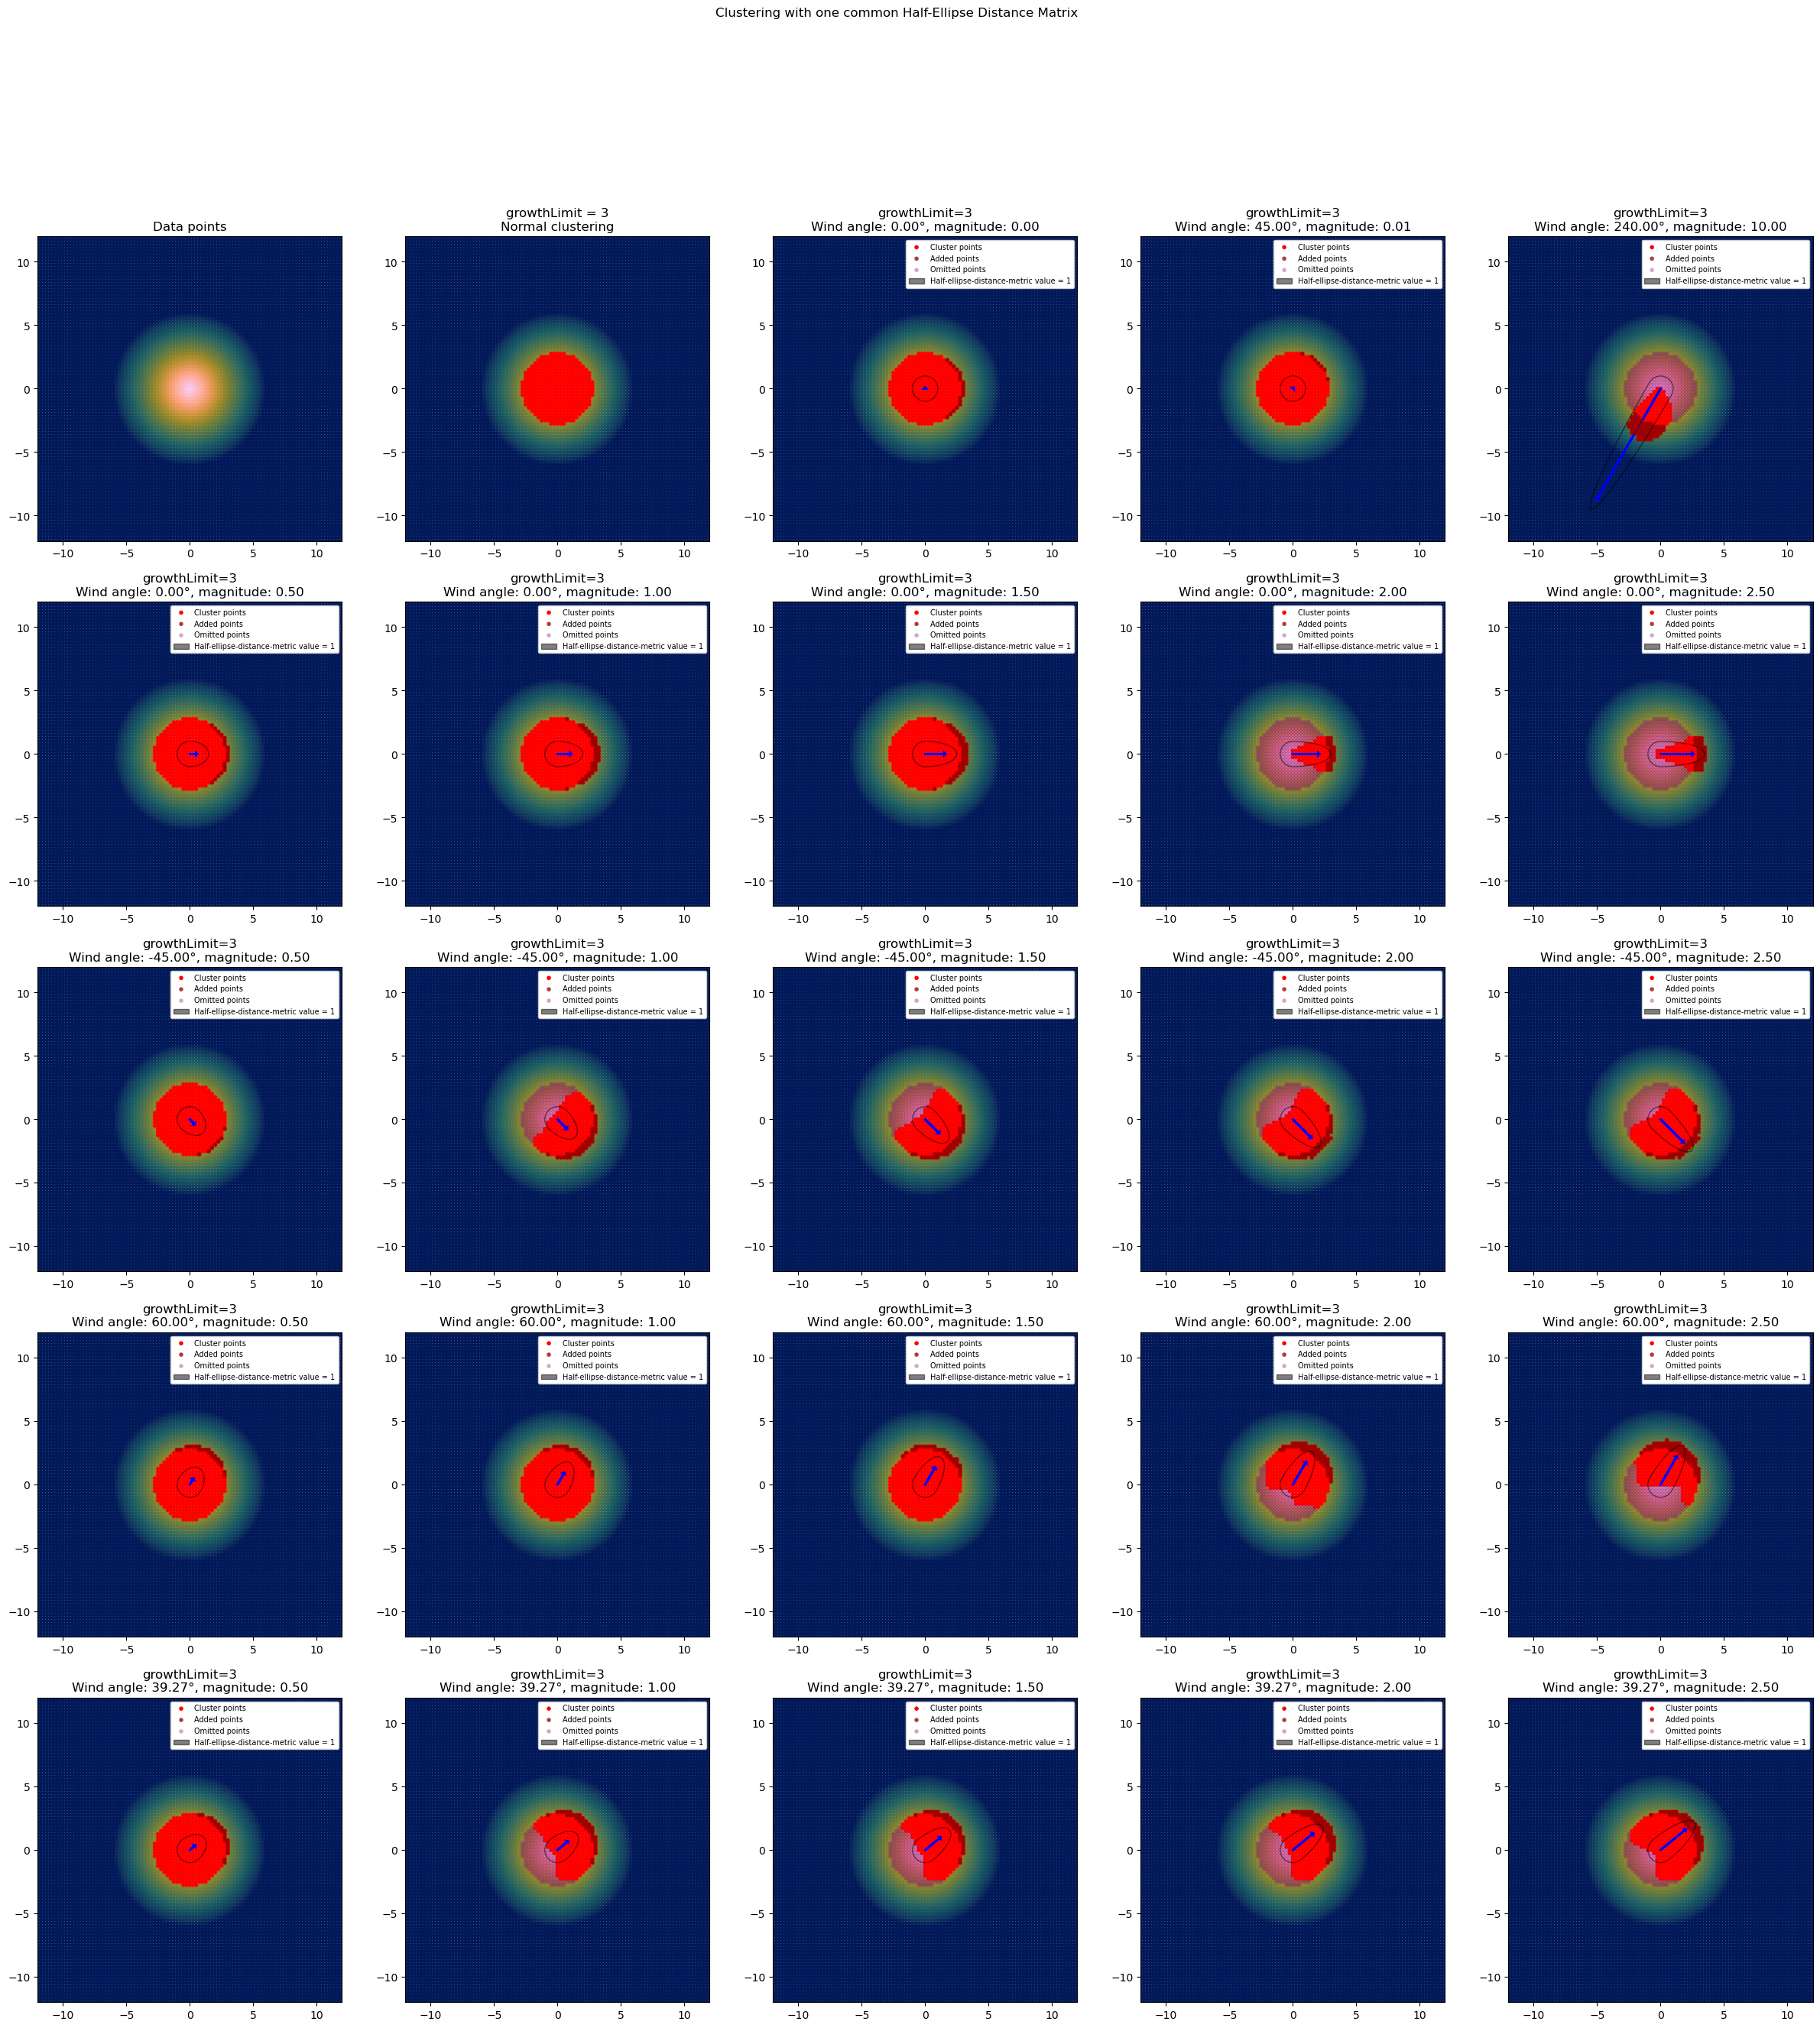

In [58]:
fig, axs = plt.subplots(5, 5, figsize=(6*5, 6*5))
axs = axs.flatten()

growth_limit = 3
extent = (-12, 12, -12, 12)


sc = axs[0].scatter(x.flatten(), y.flatten(), c=values.flatten(), s=16, edgecolors='none')
axs[0].set_aspect("equal")
axs[0].set_title("Data points")
axs[0].set_xlim(extent[0], extent[1])
axs[0].set_ylim(extent[2], extent[3])


# Normal clustering
cluster_normal = find_one_cluster_v31(
    points_linear_polar,
    values_linear_polar,
    radius_func="default",
    growth_limit=growth_limit,
    distance_matrix="euclidean",
    max_points_in_start_radius=7,
    preprocessor="Standard",
)
axs[1].scatter(x.flatten(), y.flatten(), c=values.flatten(), s=16, edgecolors='none')
axs[1].scatter(
    points_linear_polar[cluster_normal,0],
    points_linear_polar[cluster_normal,1],
    s=16,
    c="r",
    label="Cluster points",
    edgecolors='none'
)
axs[1].set_aspect("equal")
axs[1].set_title(f"growthLimit = {growth_limit}\nNormal clustering")
axs[1].set_xlim(extent[0], extent[1])
axs[1].set_ylim(extent[2], extent[3])





growth_limit = 3
wind_angles_magnitudes = [
    [0,0],
    [np.pi/4, 0.01],
    [np.pi*4/3, 10],
    [0, 0.5],
    [0,1.0],
    [0,1.5],
    [0,2.0],
    [0,2.5],
    [-np.pi/4, 0.5],
    [-np.pi/4,1.0],
    [-np.pi/4,1.5],
    [-np.pi/4,2.0],
    [-np.pi/4,2.5],
    [np.pi/3, 0.5],
    [np.pi/3,1.0],
    [np.pi/3,1.5],
    [np.pi/3,2.0],
    [np.pi/3,2.5],
    [np.pi/4-0.1,0.5],
    [np.pi/4-0.1,1.0],
    [np.pi/4-0.1,1.5],
    [np.pi/4-0.1,2.0],
    [np.pi/4-0.1,2.5],
]

for i, wind in enumerate(wind_angles_magnitudes):

    cluster = find_one_cluster_with_wind_only_distance_matrix(
        points_linear_polar,
        values_linear_polar,
        radius_func="default",
        growth_limit=growth_limit,
        distance_matrix="half_ellipse",
        max_points_in_start_radius=7,
        preprocessor="Standard",
        wind_angle=wind_angles_magnitudes[i][0],
        wind_magnitude=wind_angles_magnitudes[i][1],
    )

    sc = axs[i+2].scatter(x.flatten(), y.flatten(), c=values.flatten(), s=16, edgecolors='none')
    axs[i+2].set_aspect("equal")
    axs[i+2].scatter(
        points_linear_polar[cluster,0],
        points_linear_polar[cluster,1],
        s=16,
        c="r",
        label="Cluster points",
        edgecolors='none'
    )
    axs[i+2].set_aspect("equal")
    axs[i+2].arrow(0, 0, wind_angles_magnitudes[i][1]*np.cos(wind_angles_magnitudes[i][0]), wind_angles_magnitudes[i][1]*np.sin(wind_angles_magnitudes[i][0]), linewidth=2, head_width=0.2, head_length=0.1, fc='blue', ec='blue')
    axs[i+2].set_title(f"growthLimit={growth_limit}\nWind angle: {np.rad2deg(wind_angles_magnitudes[i][0]):.2f}\u00b0, magnitude: {wind_angles_magnitudes[i][1]:.2f}")
    # plot difference between normal clustering and wind clustering
    difference = cluster.astype(int) - cluster_normal.astype(int)
    axs[i+2].scatter(
        points_linear_polar[difference == 1,0],
        points_linear_polar[difference == 1,1],
        s=16,
        c='darkred' ,
        label="Added points",
        edgecolors='none',
        alpha=0.75
    )
    axs[i+2].scatter(
        points_linear_polar[difference == -1,0],
        points_linear_polar[difference == -1,1],
        s=16,
        c='purple' ,
        label="Omitted points",
        edgecolors='none',
        alpha=0.35
    )
    cs = axs[i+2].contour(
        meshgrid[0],
        meshgrid[1],
        half_ellipse(
            meshgrid[0],
            meshgrid[1],
            a=1 + wind_angles_magnitudes[i][1],
            b=1,
            rotation=wind_angles_magnitudes[i][0],
            rotation_unit="radians",
        ),
        levels=[1],
        colors="black",
        alpha=0.5,
        linewidths=1,
    )
    from matplotlib.lines import Line2D
    axs[i+2].arrow(0,0,0,0, color="black", alpha=0.5, label="Half-ellipse-distance-metric value = 1", linewidth=1)
    axs[i+2].legend(loc='upper right', fontsize=7, framealpha=1,)
    axs[i+2].set_xlim(extent[0], extent[1])
    axs[i+2].set_ylim(extent[2], extent[3])
                    
plt.suptitle("Clustering with one common Half-Ellipse Distance Matrix")

plt.savefig("clustering_with_wind_half_ellipse_distance_matrix.png", bbox_inches='tight',)

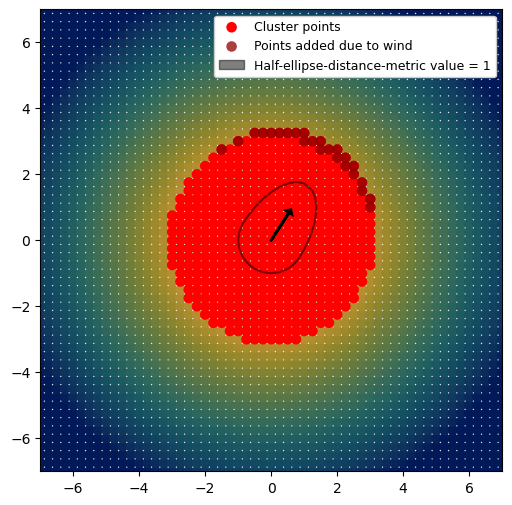

In [85]:
# Define the polar linear data
# Define the function in polar coordinates

linear_function_polar = lambda r: np.maximum(-r * 1.5 + 12, 0)

meshgrid = np.meshgrid(np.linspace(-12, 12, 97), np.linspace(-12, 12, 97))
x = meshgrid[0].flatten()
y = meshgrid[1].flatten()

# Convert Cartesian coordinates to polar coordinates
R = np.sqrt(x**2 + y**2)  # How far the grid point is from the origin

values = linear_function_polar(R)


points_linear_polar = np.array([x, y]).T
x_linear_polar = x
y_linear_polar = y
meshgrid_linear_polar = meshgrid
values_linear_polar = values
labels_linear_polar = values > 1





fig, axs = plt.subplots(1, 1, figsize=(6, 6))
#axs = axs.flatten()

growth_limit = 2.5
extent = (-7, 7, -7, 7)

"""
sc = axs[0].scatter(x.flatten(), y.flatten(), c=values.flatten(), s=58, edgecolors='none')
axs[0].set_aspect("equal")
axs[0].set_title("Data points")
axs[0].set_xlim(extent[0], extent[1])
axs[0].set_ylim(extent[2], extent[3])
"""

# Normal clustering
cluster_normal = find_one_cluster_v31(
    points_linear_polar,
    values_linear_polar,
    radius_func="default",
    growth_limit=growth_limit,
    distance_matrix="euclidean",
    max_points_in_start_radius=7,
    preprocessor="Standard",
)

"""
axs[1].scatter(x.flatten(), y.flatten(), c=values.flatten(), s=58, edgecolors='none')
axs[1].scatter(
    points_linear_polar[cluster_normal,0],
    points_linear_polar[cluster_normal,1],
    s=58,
    c="r",
    label="Cluster points",
    edgecolors='none'
)
axs[1].set_aspect("equal")
axs[1].set_title(f"growthLimit = {growth_limit}\nNormal clustering")
axs[1].set_xlim(extent[0], extent[1])
axs[1].set_ylim(extent[2], extent[3])
"""




growth_limit = 2.5
wind_angles_magnitudes = [
    [1,1],
]

for i, wind in enumerate(wind_angles_magnitudes):

    cluster = find_one_cluster_with_wind_only_distance_matrix(
        points_linear_polar,
        values_linear_polar,
        radius_func="default",
        growth_limit=growth_limit,
        distance_matrix="half_ellipse",
        max_points_in_start_radius=7,
        preprocessor="Standard",
        wind_angle=wind_angles_magnitudes[i][0],
        wind_magnitude=wind_angles_magnitudes[i][1],
    )

    sc = axs.scatter(x.flatten(), y.flatten(), c=values.flatten(), s=58, edgecolors='none')
    axs.set_aspect("equal")
    axs.scatter(
        points_linear_polar[cluster,0],
        points_linear_polar[cluster,1],
        s=58,
        c="r",
        label="Cluster points",
        edgecolors='none'
    )
    axs.set_aspect("equal")
    axs.arrow(0, 0, wind_angles_magnitudes[i][1]*np.cos(wind_angles_magnitudes[i][0]), wind_angles_magnitudes[i][1]*np.sin(wind_angles_magnitudes[i][0]), linewidth=2, head_width=0.2, head_length=0.1, fc='black', ec='black')
    #axs.set_title(f"growthLimit={growth_limit}\nWind angle: {np.rad2deg(wind_angles_magnitudes[i][0]):.2f}\u00b0, magnitude: {wind_angles_magnitudes[i][1]:.2f}")
    # plot difference between normal clustering and wind clustering
    difference = cluster.astype(int) - cluster_normal.astype(int)
    axs.scatter(
        points_linear_polar[difference == 1,0],
        points_linear_polar[difference == 1,1],
        s=58,
        c='darkred' ,
        label="Points added due to wind",
        edgecolors='none',
        alpha=0.75
    )
    #axs.scatter(
    #    points_linear_polar[difference == -1,0],
    #    points_linear_polar[difference == -1,1],
    #    s=58,
    #    c='purple' ,
    #    label="Omitted points",
    #    edgecolors='none',
    #    alpha=0.35
    #)
    cs = axs.contour(
        meshgrid[0],
        meshgrid[1],
        half_ellipse(
            meshgrid[0],
            meshgrid[1],
            a=1 + wind_angles_magnitudes[i][1],
            b=1,
            rotation=wind_angles_magnitudes[i][0],
            rotation_unit="radians",
        ),
        levels=[1],
        colors="black",
        alpha=0.5,
        linewidths=1.5,
    )
    from matplotlib.lines import Line2D
    axs.arrow(0,0,0,0, color="black", alpha=0.5, label="Half-ellipse-distance-metric value = 1", linewidth=1)
    axs.legend(loc='upper right', fontsize=9, framealpha=1,)
    axs.set_xlim(extent[0], extent[1])
    axs.set_ylim(extent[2], extent[3])
                    
#plt.suptitle("Clustering with one common Half-Ellipse Distance Matrix")

plt.savefig("clustering_with_wind_half_ellipse_distance_matrix_single.png", bbox_inches='tight', transparent=True)

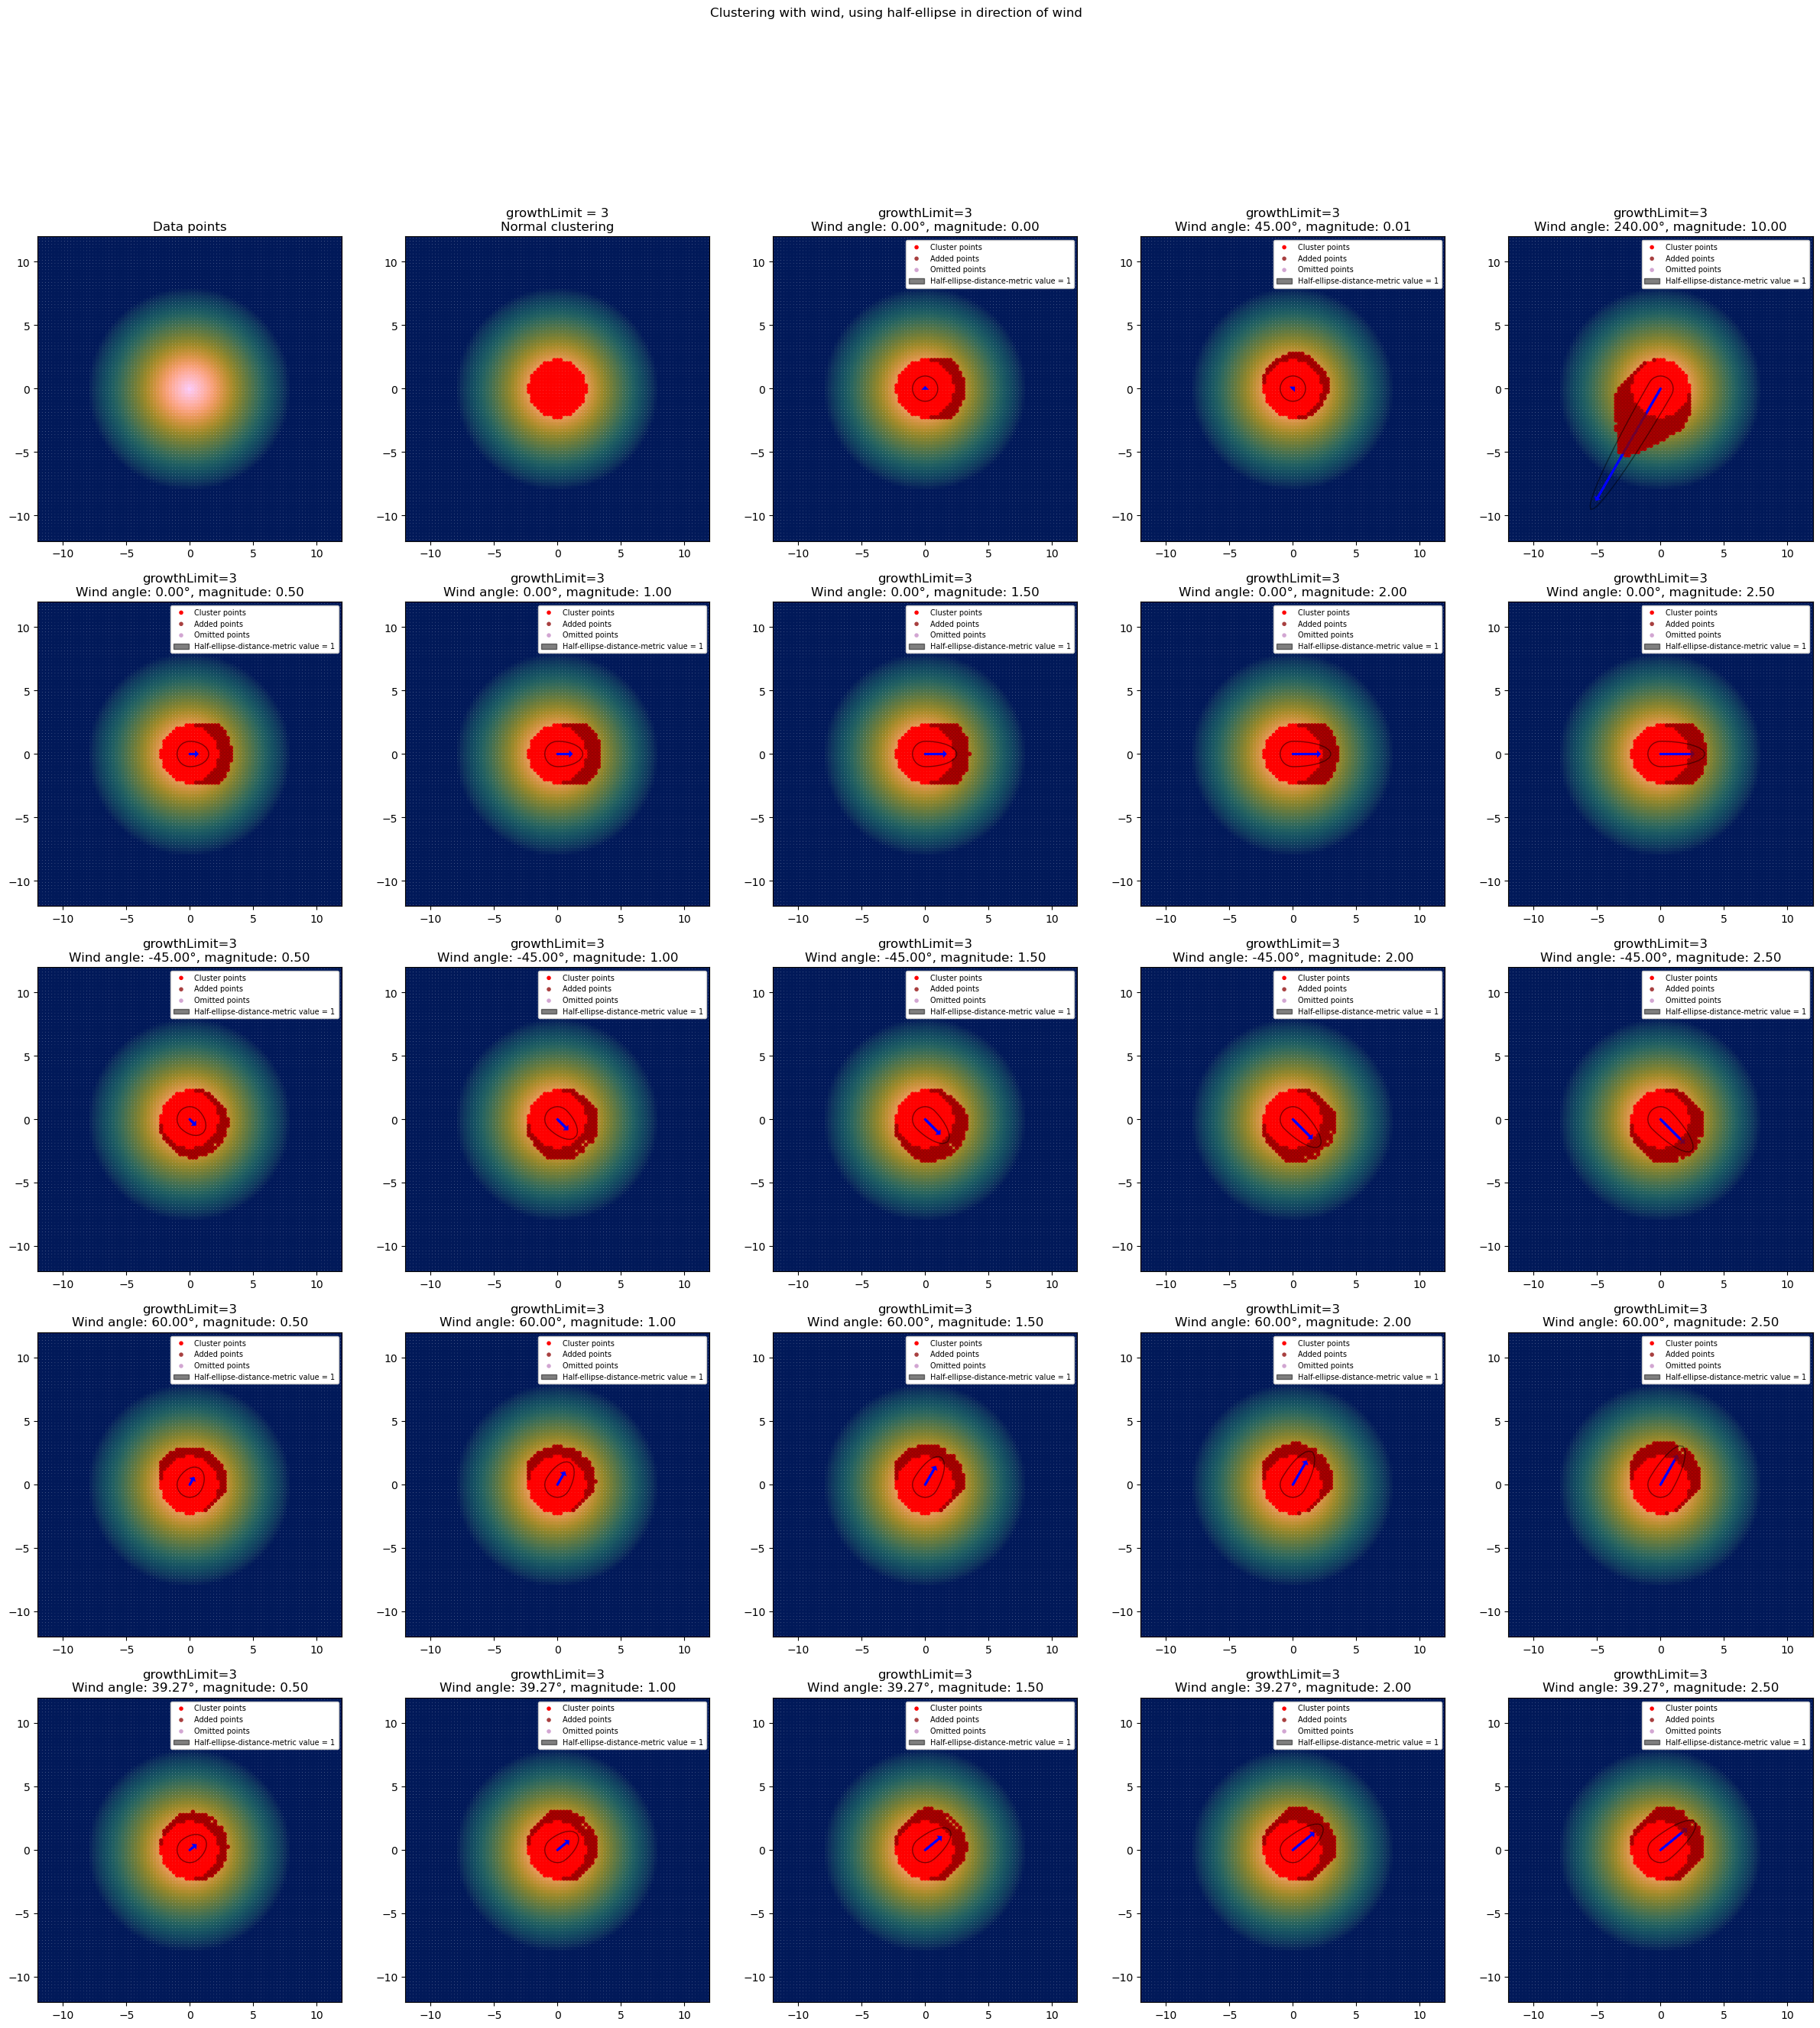

In [60]:
fig, axs = plt.subplots(5, 5, figsize=(6*5, 6*5))
axs = axs.flatten()

growth_limit = 3
extent = (-12, 12, -12, 12)


sc = axs[0].scatter(x.flatten(), y.flatten(), c=values.flatten(), s=16, edgecolors='none')
axs[0].set_aspect("equal")
axs[0].set_title("Data points")
axs[0].set_xlim(extent[0], extent[1])
axs[0].set_ylim(extent[2], extent[3])


# Normal clustering
cluster_normal = find_one_cluster_v31(
    points_linear_polar,
    values_linear_polar,
    radius_func="default",
    growth_limit=growth_limit,
    distance_matrix="euclidean",
    max_points_in_start_radius=7,
    preprocessor="Standard",
)
axs[1].scatter(x.flatten(), y.flatten(), c=values.flatten(), s=16, edgecolors='none')
axs[1].scatter(
    points_linear_polar[cluster_normal,0],
    points_linear_polar[cluster_normal,1],
    s=16,
    c="r",
    label="Cluster points",
    edgecolors='none'
)
axs[1].set_aspect("equal")
axs[1].set_title(f"growthLimit = {growth_limit}\nNormal clustering")
axs[1].set_xlim(extent[0], extent[1])
axs[1].set_ylim(extent[2], extent[3])





growth_limit = 3
wind_angles_magnitudes = [
    [0,0],
    [np.pi/4, 0.01],
    [np.pi*4/3, 10],
    [0, 0.5],
    [0,1.0],
    [0,1.5],
    [0,2.0],
    [0,2.5],
    [-np.pi/4, 0.5],
    [-np.pi/4,1.0],
    [-np.pi/4,1.5],
    [-np.pi/4,2.0],
    [-np.pi/4,2.5],
    [np.pi/3, 0.5],
    [np.pi/3,1.0],
    [np.pi/3,1.5],
    [np.pi/3,2.0],
    [np.pi/3,2.5],
    [np.pi/4-0.1,0.5],
    [np.pi/4-0.1,1.0],
    [np.pi/4-0.1,1.5],
    [np.pi/4-0.1,2.0],
    [np.pi/4-0.1,2.5],
]

for i, wind in enumerate(wind_angles_magnitudes):

    cluster = find_one_cluster_with_wind_larger_radius(
        points_linear_polar,
        values_linear_polar,
        radius_func="default",
        growth_limit=growth_limit,
        distance_matrix="half_ellipse",
        max_points_in_start_radius=7,
        preprocessor="Standard",
        wind_angle=wind_angles_magnitudes[i][0],
        wind_magnitude=wind_angles_magnitudes[i][1],
    )

    sc = axs[i+2].scatter(x.flatten(), y.flatten(), c=values.flatten(), s=16, edgecolors='none')
    axs[i+2].set_aspect("equal")
    axs[i+2].scatter(
        points_linear_polar[cluster,0],
        points_linear_polar[cluster,1],
        s=16,
        c="r",
        label="Cluster points",
        edgecolors='none'
    )
    axs[i+2].set_aspect("equal")
    axs[i+2].arrow(0, 0, wind_angles_magnitudes[i][1]*np.cos(wind_angles_magnitudes[i][0]), wind_angles_magnitudes[i][1]*np.sin(wind_angles_magnitudes[i][0]), linewidth=2, head_width=0.2, head_length=0.1, fc='blue', ec='blue')
    axs[i+2].set_title(f"growthLimit={growth_limit}\nWind angle: {np.rad2deg(wind_angles_magnitudes[i][0]):.2f}\u00b0, magnitude: {wind_angles_magnitudes[i][1]:.2f}")
    # plot difference between normal clustering and wind clustering
    difference = cluster.astype(int) - cluster_normal.astype(int)
    axs[i+2].scatter(
        points_linear_polar[difference == 1,0],
        points_linear_polar[difference == 1,1],
        s=16,
        c='darkred' ,
        label="Added points",
        edgecolors='none',
        alpha=0.75
    )
    axs[i+2].scatter(
        points_linear_polar[difference == -1,0],
        points_linear_polar[difference == -1,1],
        s=16,
        c='purple' ,
        label="Omitted points",
        edgecolors='none',
        alpha=0.35
    )
    cs = axs[i+2].contour(
        meshgrid[0],
        meshgrid[1],
        half_ellipse(
            meshgrid[0],
            meshgrid[1],
            a=1 + wind_angles_magnitudes[i][1],
            b=1,
            rotation=wind_angles_magnitudes[i][0],
            rotation_unit="radians",
        ),
        levels=[1],
        colors="black",
        alpha=0.5,
        linewidths=1,
    )
    from matplotlib.lines import Line2D
    axs[i+2].arrow(0,0,0,0, color="black", alpha=0.5, label="Half-ellipse-distance-metric value = 1", linewidth=1)
    axs[i+2].legend(loc='upper right', fontsize=7, framealpha=1,)
    axs[i+2].set_xlim(extent[0], extent[1])
    axs[i+2].set_ylim(extent[2], extent[3])
                    
plt.suptitle("Clustering with wind, using half-ellipse in direction of wind")

plt.savefig("clustering_with_wind_half_ellipse_larger_radius.png", bbox_inches='tight',)

In [26]:
wind_angle, wind_magnitude = wind_to_angle_and_magnitude(np.array([-1,0.5])*0.0)
np.cos(wind_angle)

np.float64(1.0)

In [27]:
np.array([-1,0.5])*0
np.cos(-0.)


np.float64(1.0)

# First test on real world data

## Combine ERA5 and TROPOMI

In [29]:
# Read .grib file to get wind data

import pygrib
era5_file_location = '/Volumes/One Touch/ERA5/data.grib'

import xarray as xr

era5 = xr.open_dataset(
    era5_file_location,
    engine="cfgrib",
    backend_kwargs={"indexpath": ""}
)

ValueError: unrecognized engine 'cfgrib' must be one of your download engines: ['scipy', 'store']. To install additional dependencies, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html

In [ ]:
era5

<xarray.Dataset> Size: 4GB
Dimensions:     (time: 4026, latitude: 181, longitude: 201)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 32kB 2024-01-01T07:00:00 ... 2024-12-31...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
  * latitude    (latitude) float64 1kB 75.0 74.75 74.5 74.25 ... 30.5 30.25 30.0
  * longitude   (longitude) float64 2kB -15.0 -14.75 -14.5 ... 34.5 34.75 35.0
    valid_time  (time) datetime64[ns] 32kB ...
Data variables:
    u10         (time, latitude, longitude) float32 586MB ...
    v10         (time, latitude, longitude) float32 586MB ...
    meanSea     float64 8B ...
    u100        (time, latitude, longitude) float32 586MB ...
    v100        (time, latitude, longitude) float32 586MB ...
    u10n        (time, latitude, longitude) float32 586MB ...
    v10n        (time, latitude, longitude) float32 586MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-12-11T17:04 GRIB to CDM+CF via cfgrib-0.9.1...

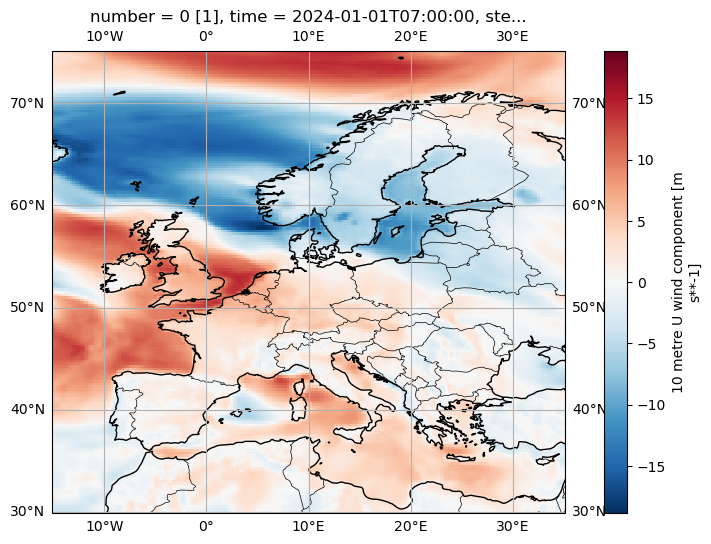

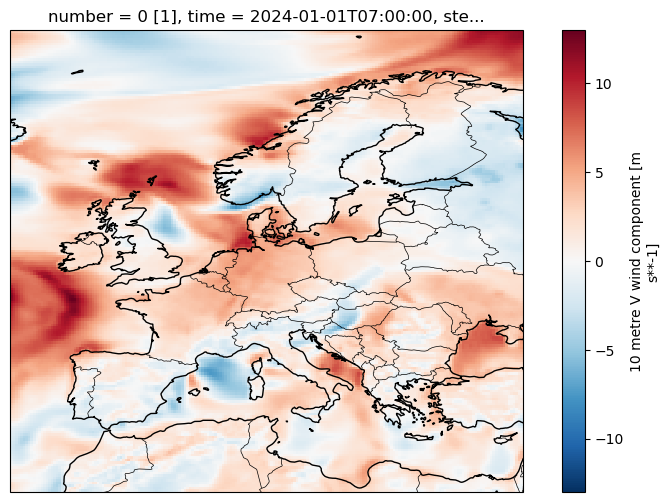

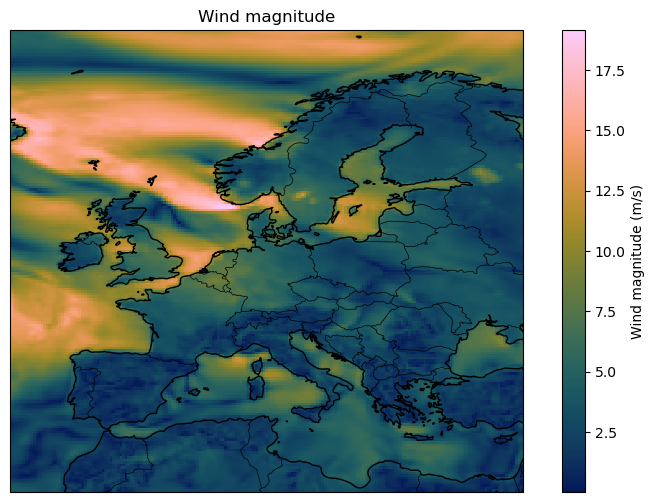

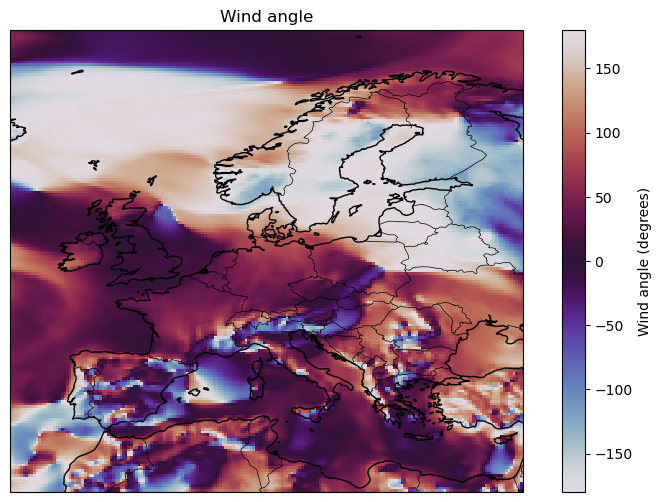

In [ ]:
# Plot wind data

# Create figure with cartopy projection for u10
fig, ax = plt.subplots(1, 1, figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
u10 = era5['u10'].isel(time=0)
u10.plot(ax=ax)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
ax.gridlines(draw_labels=True)
plt.show()

# Create figure with cartopy projection for v10
fig, ax = plt.subplots(1, 1, figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
v10 = era5['v10'].isel(time=0)
v10.plot(ax=ax)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
plt.show()

wind_angle, wind_magnitude = wind_to_angle_and_magnitude(np.stack([u10.values, v10.values], axis=-1))

# Create figure with cartopy projection for wind magnitude
fig, ax = plt.subplots(1, 1, figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.pcolormesh(era5['longitude'], era5['latitude'], wind_magnitude, transform=ccrs.PlateCarree())
ax.set_title('Wind magnitude')
plt.colorbar(ax.collections[0], ax=ax, label='Wind magnitude (m/s)')
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
plt.show()

# Create figure with cartopy projection for wind angle
fig, ax = plt.subplots(1, 1, figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.pcolormesh(era5['longitude'], era5['latitude'], np.rad2deg(wind_angle), cmap='twilight', vmin=-180, vmax=180, transform=ccrs.PlateCarree())
ax.set_title('Wind angle')
plt.colorbar(ax.collections[0], ax=ax, label='Wind angle (degrees)')
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
plt.show()


# Add wind direction and magnitude to the era5 dataset
era5['wind_angle'] = (('latitude', 'longitude'), wind_angle)
era5['wind_magnitude'] = (('latitude', 'longitude'), wind_magnitude)

In [ ]:
# Tropomi NO2 data

tropomi_data_directory = "/Volumes/One Touch/Sentinel-5p NO2 Europe/S5P_NO2_June2024"
S5P_FILENAMES = sorted(glob.glob(os.path.join(tropomi_data_directory, "*.nc")))
print(f"Found {len(S5P_FILENAMES)} S5P files.")


ds = crop_to_bbox(
    S5P_FILENAMES[17],
    )
ds

Found 292 S5P files.
[+] Pre-processing data files ...


<xarray.Dataset> Size: 57MB
Dimensions:                                               (time: 1,
                                                           scanline: 735,
                                                           ground_pixel: 441,
                                                           layer: 34,
                                                           vertices: 2,
                                                           corner: 4,
                                                           polynomial_exponents: 6,
                                                           intensity_offset_polynomial_exponents: 1)
Coordinates:
  * scanline                                              (scanline) float64 6kB ...
  * ground_pixel                                          (ground_pixel) float64 4kB ...
  * time                                                  (time) datetime64[ns] 8B ...
  * corner                                                (corner) float64 32B ...
  * polynomial_exponents                                  (polynomial_exponents) float64 48B ...
  * intensity_offset_polynomial_exponents                 (intensity_offset_polynomial_exponents) float64 8B ...
  * layer                                                 (layer) float64 272B ...
  * vertices                                              (vertices) float64 16B ...
    latitude                                              (time, scanline, ground_pixel) float32 1MB ...
    longitude                                             (time, scanline, ground_pixel) float32 1MB ...
Data variables:
    delta_time                                            (time, scanline) datetime64[ns] 6kB ...
    time_utc                                              (time, scanline) object 6kB ...
    qa_value                                              (time, scanline, ground_pixel) float32 1MB ...
    nitrogendioxide_tropospheric_column                   (time, scanline, ground_pixel) float32 1MB ...
    nitrogendioxide_tropospheric_column_precision         (time, scanline, ground_pixel) float32 1MB ...
    nitrogendioxide_tropospheric_column_precision_kernel  (time, scanline, ground_pixel) float32 1MB ...
    averaging_kernel                                      (time, scanline, ground_pixel, layer) float32 44MB ...
    air_mass_factor_troposphere                           (time, scanline, ground_pixel) float32 1MB ...
    air_mass_factor_total                                 (time, scanline, ground_pixel) float32 1MB ...
    tm5_tropopause_layer_index                            (time, scanline, ground_pixel) float64 3MB ...
    tm5_constant_a                                        (layer, vertices) float32 272B ...
    tm5_constant_b                                        (layer, vertices) float32 272B ...

Text(0.5, 1.0, 'Tropomi NO2 Tropospheric Column\nQA > 0.75\ndate: 2024-06-02T12:45:41.871000Z')

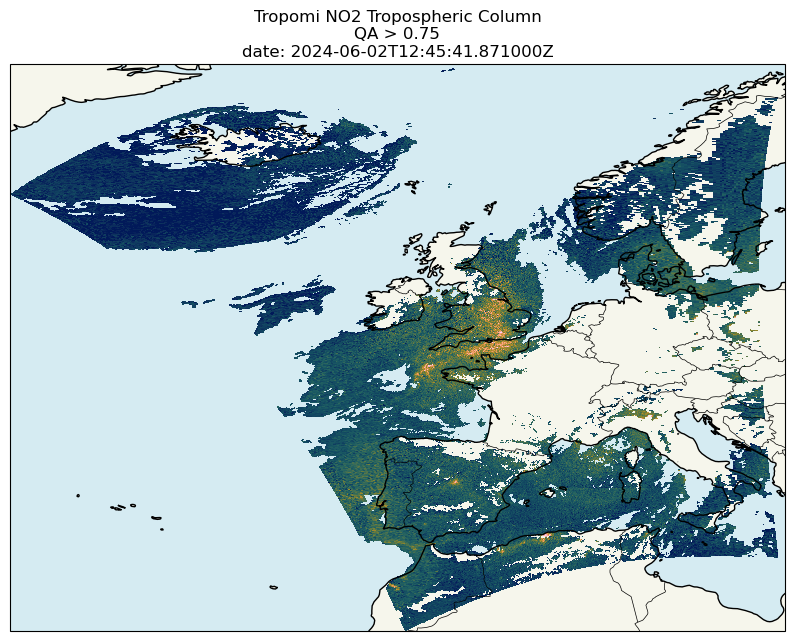

In [ ]:
fig, axs = plt.subplots(1,1,figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax = axs

qa_value=0.75
mask = (ds['qa_value'] > qa_value)[0]
no2 = ds['nitrogendioxide_tropospheric_column'][0].data
no2_masked = np.where(mask, no2, np.nan)


# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)

ax.pcolormesh(
    ds['longitude'][0].data, 
    ds['latitude'][0].data, 
    no2_masked,
    shading='auto',
    vmin=0, vmax=0.0001,
)

ax.set_title(f"Tropomi NO2 Tropospheric Column\nQA > {qa_value}\ndate: {ds['time_utc'][0][0].data}")

In [ ]:
wind_magnitude_tropomi = era5.wind_magnitude.sel(latitude=ds.latitude[0], longitude=ds.longitude[0], method='nearest')
wind_angle_tropomi = era5.wind_angle.sel(latitude=ds.latitude[0], longitude=ds.longitude[0], method='nearest')
wind_magnitude_tropomi

<xarray.DataArray 'wind_magnitude' (scanline: 735, ground_pixel: 441)> Size: 1MB
array([[2.9357069, 2.36812  , 2.36812  , ..., 5.7890377, 5.7890377,
        5.659919 ],
       [2.9357069, 2.36812  , 2.36812  , ..., 5.7890377, 5.7890377,
        5.659919 ],
       [2.9357069, 2.36812  , 2.36812  , ..., 5.7890377, 5.7890377,
        5.659919 ],
       ...,
       [5.477285 , 5.477285 , 5.81548  , ..., 4.5986266, 4.611461 ,
        4.642064 ],
       [5.477285 , 5.81548  , 5.81548  , ..., 4.611461 , 4.611461 ,
        4.642064 ],
       [5.477285 , 5.81548  , 5.81548  , ..., 5.6347613, 5.6615095,
        5.6615095]], dtype=float32)
Coordinates:
    number        int64 8B ...
    step          timedelta64[ns] 8B ...
    surface       float64 8B ...
    latitude      (scanline, ground_pixel) float64 3MB 30.0 30.0 ... 70.25 70.25
    longitude     (scanline, ground_pixel) float64 3MB -7.5 -7.25 ... 20.0 20.0
  * scanline      (scanline) float64 6kB 2.241e+03 2.242e+03 ... 2.975e+03
  * ground_pixel  (ground_pixel) float64 4kB 9.0 10.0 11.0 ... 447.0 448.0 449.0
    time          datetime64[ns] 8B 2024-06-02

In [ ]:
wind_angle_tropomi

<xarray.DataArray 'wind_angle' (scanline: 735, ground_pixel: 441)> Size: 1MB
array([[-0.9940786 , -1.179794  , -1.179794  , ...,  0.37859356,
         0.37859356,  0.42582428],
       [-0.9940786 , -1.179794  , -1.179794  , ...,  0.37859356,
         0.37859356,  0.42582428],
       [-0.9940786 , -1.179794  , -1.179794  , ...,  0.37859356,
         0.37859356,  0.42582428],
       ...,
       [ 3.05518   ,  3.05518   ,  2.965358  , ...,  1.361328  ,
         1.3515172 ,  1.3387427 ],
       [ 3.05518   ,  2.965358  ,  2.965358  , ...,  1.3515172 ,
         1.3515172 ,  1.3387427 ],
       [ 3.05518   ,  2.965358  ,  2.965358  , ...,  1.0863512 ,
         1.0792732 ,  1.0792732 ]], dtype=float32)
Coordinates:
    number        int64 8B ...
    step          timedelta64[ns] 8B ...
    surface       float64 8B ...
    latitude      (scanline, ground_pixel) float64 3MB 30.0 30.0 ... 70.25 70.25
    longitude     (scanline, ground_pixel) float64 3MB -7.5 -7.25 ... 20.0 20.0
  * scanline      (scanline) float64 6kB 2.241e+03 2.242e+03 ... 2.975e+03
  * ground_pixel  (ground_pixel) float64 4kB 9.0 10.0 11.0 ... 447.0 448.0 449.0
    time          datetime64[ns] 8B 2024-06-02

Text(0.5, 1.0, 'ERA5 Wind Magnitude on Tropomi Grid')

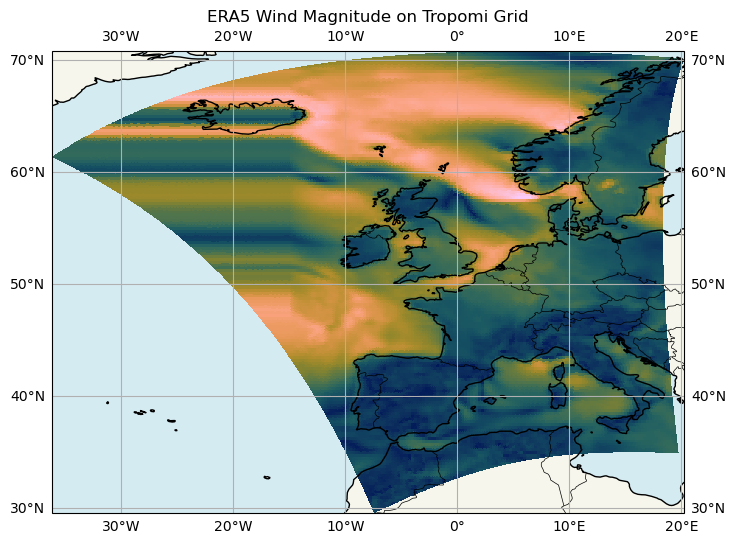

In [ ]:
# Era5 wind magnitude in tropomi grid

fig, ax = plt.subplots(1, 1, figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})


ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
ax.gridlines(draw_labels=True)

plt.pcolormesh(
    ds['longitude'][0].data, 
    ds['latitude'][0].data, 
    wind_magnitude_tropomi,
    shading='auto',
)

ax.set_title('ERA5 Wind Magnitude on Tropomi Grid')

In [ ]:
ds['longitude'][0].data.shape

350*350

122500

In [ ]:
distance_matrix = calc_half_ellipse_distance_matrix(
    ds['longitude'][0].data.flatten()[:100], 
    ds['latitude'][0].data.flatten()[:100], 
    wind_magnitude_tropomi.data.flatten()[:100],
    wind_angle_tropomi.data.flatten()[:100],
)

In [ ]:
distance_matrix

array([[0.        , 0.08320626, 0.16541839, ..., 8.02216339, 8.0750103 ,
        8.12750149],
       [0.08377379, 0.        , 0.08289149, ..., 8.06567192, 8.12000561,
        8.1739893 ],
       [0.16655828, 0.08278447, 0.        , ..., 7.98289013, 8.03722572,
        8.09121132],
       ...,
       [8.14944553, 8.06567192, 7.98288965, ..., 0.        , 0.02804304,
        0.05587789],
       [8.20377827, 8.12000561, 8.03722572, ..., 0.05445985, 0.        ,
        0.02064579],
       [8.25775814, 8.1739893 , 8.09121037, ..., 0.10857104, 0.05411121,
        0.        ]])

## Test with SCEA

[+] Pre-processing data files ...


Text(0.5, 1.0, 'Tropomi NO2 Tropospheric Column\nQA > 0.74\ndate: 2024-06-04T10:26:08.071000Z')

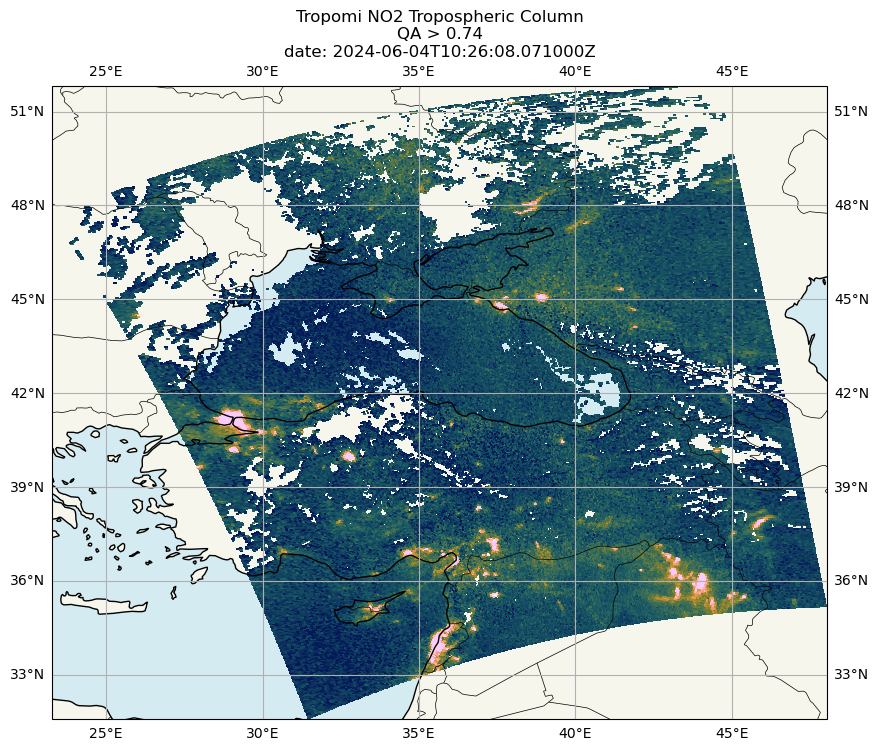

In [ ]:
ds = crop_to_bbox(
    S5P_FILENAMES[36],
    bbox = [30.0, 35.0, 45.0, 50.0]
    )


fig, axs = plt.subplots(1,1,figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax = axs

qa_value=0.74
mask = (ds['qa_value'] > qa_value)[0]
no2 = ds['nitrogendioxide_tropospheric_column'][0].data
no2_masked = np.where(mask, no2, np.nan)


# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
ax.gridlines(draw_labels=True)
ax.pcolormesh(
    ds['longitude'][0].data, 
    ds['latitude'][0].data, 
    no2_masked,
    shading='auto',
    vmin=0, vmax=0.0001,
)

ax.set_title(f"Tropomi NO2 Tropospheric Column\nQA > {qa_value}\ndate: {ds['time_utc'][0][0].data}")

In [ ]:
# Cluster with SCEA
import sys
sys.path.insert(0, "/Users/eliaserv/Documents/VSCode_projects/SCEA/SCEA/")          # adjust .. or ../.. as needed
from SCEA import SCEA  # import the class/function

point_values = no2_masked.flatten()
nan_mask = np.isnan(point_values)
point_values = point_values[~nan_mask]
point_coordinates = np.array([ds['longitude'][0].data.flatten(), ds['latitude'][0].data.flatten()]).T[~nan_mask]
point_coordinates.shape

(94338, 2)

Found  67  clusters


Text(0.5, 1.0, 'Tropomi NO2 Tropospheric Column\nQA > 0.74\ndate: 2024-06-04T10:26:08.071000Z')

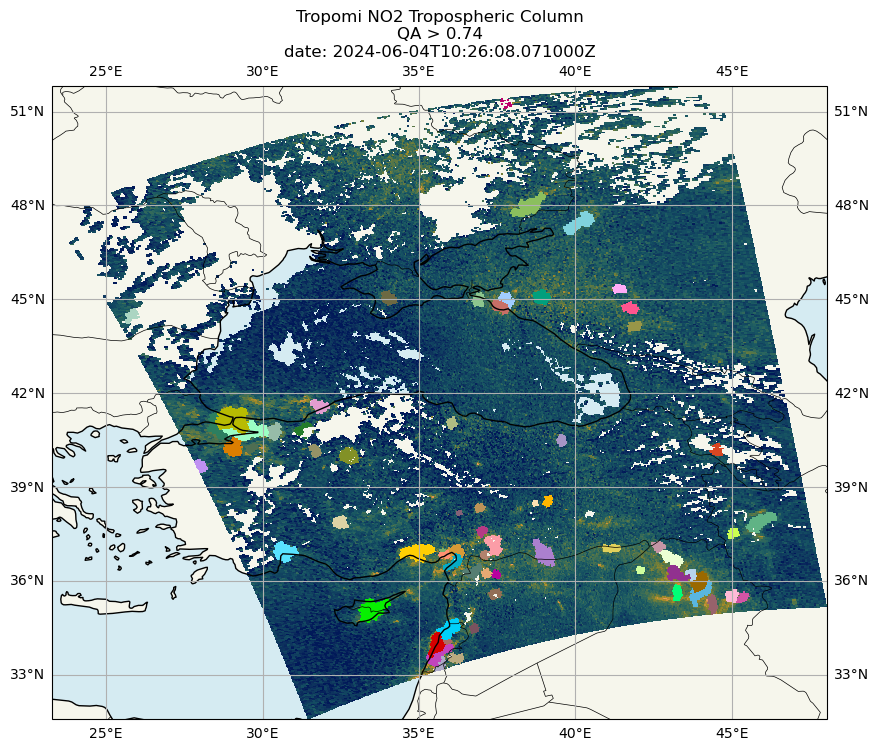

In [ ]:
clusters = SCEA(
    point_coordinates,
    point_values,
    growth_limit=2,
    detection_limit=3.5,
    local_box_size=3
)

fig, axs = plt.subplots(1,1,figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax = axs

qa_value=0.74
mask = (ds['qa_value'] > qa_value)[0]
no2 = ds['nitrogendioxide_tropospheric_column'][0].data
no2_masked = np.where(mask, no2, np.nan)


# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
ax.gridlines(draw_labels=True)
ax.pcolormesh(
    ds['longitude'][0].data, 
    ds['latitude'][0].data, 
    no2_masked,
    shading='auto',
    vmin=0, vmax=0.0001,
)


clusters_full = np.full(ds['nitrogendioxide_tropospheric_column'][0].data.flatten().shape, 0.0, dtype=float)
clusters_full[~nan_mask] = clusters
clusters_full[clusters_full == 0] = np.nan
clusters_full = clusters_full.reshape(ds['nitrogendioxide_tropospheric_column'][0].data.shape)


ax.pcolormesh(
    ds['longitude'][0].data, 
    ds['latitude'][0].data, 
    clusters_full,
    shading='auto',
    cmap=cc.cm.glasbey_light,
)

"""
for i in range(int(np.max(clusters))+1):
    if i == 0:
        continue  # skip cluster 0 (no cluster)
    cluster_points = point_coordinates[clusters == i]
    ax.scatter(
        cluster_points[:,0],
        cluster_points[:,1],
        s=10,
        alpha=0.7,
    )
"""


ax.set_title(f"Tropomi NO2 Tropospheric Column\nQA > {qa_value}\ndate: {ds['time_utc'][0][0].data}")

Found  67  clusters


Text(0.5, 1.0, 'Tropomi NO2 Tropospheric Column\nQA > 0.74\ndate: 2024-06-04T10:26:08.071000Z')

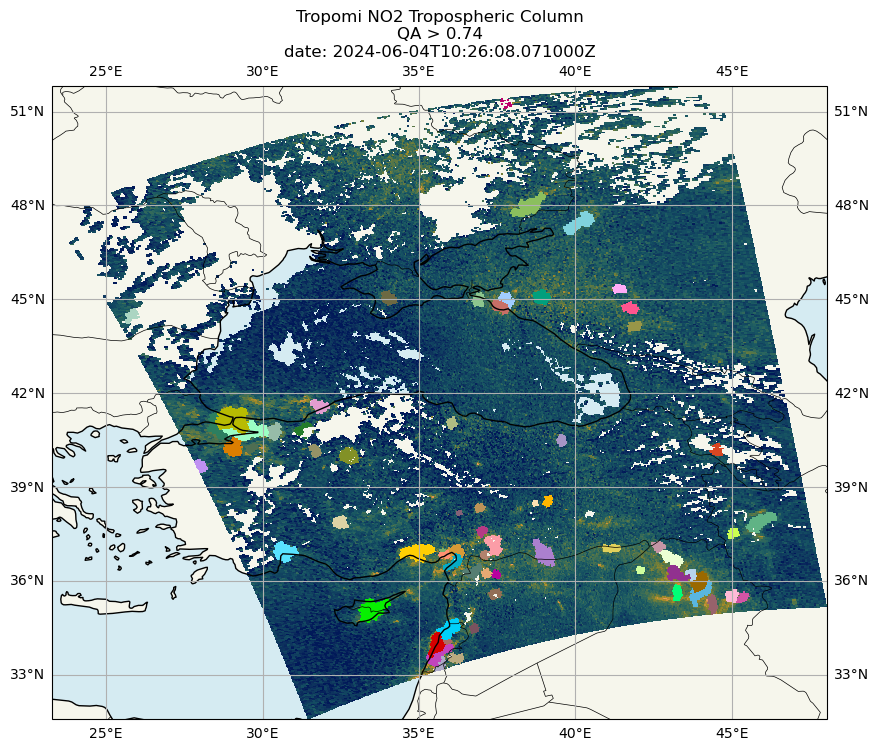

In [ ]:
clusters = SCEA(
    point_coordinates,
    point_values,
    growth_limit=2,
    detection_limit=3.5,
    local_box_size=3
)

fig, axs = plt.subplots(1,1,figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax = axs

qa_value=0.74
mask = (ds['qa_value'] > qa_value)[0]
no2 = ds['nitrogendioxide_tropospheric_column'][0].data
no2_masked = np.where(mask, no2, np.nan)


# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
ax.gridlines(draw_labels=True)
ax.pcolormesh(
    ds['longitude'][0].data, 
    ds['latitude'][0].data, 
    no2_masked,
    shading='auto',
    vmin=0, vmax=0.0001,
)


clusters_full = np.full(ds['nitrogendioxide_tropospheric_column'][0].data.flatten().shape, 0.0, dtype=float)
clusters_full[~nan_mask] = clusters
clusters_full[clusters_full == 0] = np.nan
clusters_full = clusters_full.reshape(ds['nitrogendioxide_tropospheric_column'][0].data.shape)


ax.pcolormesh(
    ds['longitude'][0].data, 
    ds['latitude'][0].data, 
    clusters_full,
    shading='auto',
    cmap=cc.cm.glasbey_light,
)

"""
for i in range(int(np.max(clusters))+1):
    if i == 0:
        continue  # skip cluster 0 (no cluster)
    cluster_points = point_coordinates[clusters == i]
    ax.scatter(
        cluster_points[:,0],
        cluster_points[:,1],
        s=10,
        alpha=0.7,
    )
"""


ax.set_title(f"Tropomi NO2 Tropospheric Column\nQA > {qa_value}\ndate: {ds['time_utc'][0][0].data}")